# **Setting 1**

$X = \mu + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \ \sigma^2I)$

Randomly select $j \in [p]$

Hypothesis:
$H_0: \mu_j = 0, \quad H_1: \mu_j \neq 0$

Test statistic: $T = x_j = \eta_j^TX$ <br><br>

### Nhận định

Sau khi hist tất cả giá trị của p-value lên, ta được kết quả là 1 phân phối đều !?

Ta sử dụng kết quả của định lý sau https://en.wikipedia.org/wiki/Probability_integral_transform

*Xét $X$ là biến ngẫu nhiên tuân theo phân phối liên tục với hàm phân phối tích lũy là $F_X$. Ta có được biến ngẫu nhiên $Y$ được định nghĩa là $Y := F_X(X)$ tuân theo phân phối đều trong đoạn từ 0 đến 1 : $\ \ Y \sim U(0, \ 1)$*

Thật vậy, ta có giá trị của p-value được tính bằng $2 * min(F_X(x), \ 1 - F_X(x))$

Xét $P = h(U) = h(F_X(X)),$ với $\ h(u) = 2 * min(u, \ 1 - u)$

Với $0 <= \alpha <= 1,$
 $$
\begin{align}
P(P \le \alpha)
   &= P\!\left( 2 \min(U, \ 1 - U) \le \alpha \right) \\
   &= P\!\left( \min(U, \ 1 - U) \le \tfrac{\alpha}{2} \right) \\
   &= P(U \le \tfrac{\alpha}{2}) + P(U \ge 1 - \tfrac{\alpha}{2}) \\
   &= P(U \le \tfrac{\alpha}{2}) + 1 - P(U \le 1 - \tfrac{\alpha}{2}) \\
   &= \tfrac{\alpha}{2} + 1 - (1 - \tfrac{\alpha}{2}) \\
   &= \alpha
\end{align}
$$

Suy ra ta có được $P$ tuân theo phân phối đều


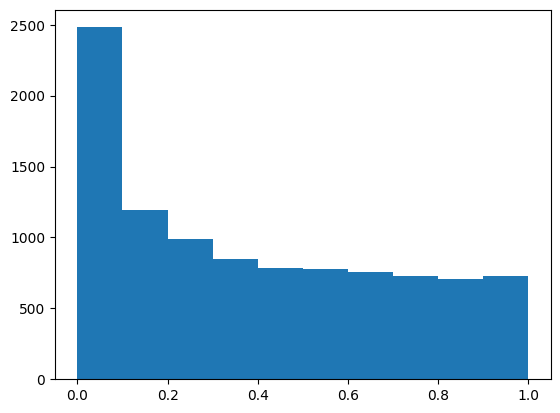

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import random

def generate(n):
    X = np.random.normal(loc = 0, scale = 1, size = (n, 1))
    noise = np.random.normal(loc = 0, scale = 1, size = (n, 1))
    X = X + noise
    return X

def run(x):
    cdf = norm.cdf(x[0][0], loc = 0, scale = 1)
    p_value = 2 * min(cdf, 1 - cdf)

    return p_value

if __name__ == '__main__':
    n = 100
    max_iteration = 10000

    list_p_value = []
    for _ in range(max_iteration):
        X = generate(n)

        eta = np.zeros((n, 1))
        eta[0][0] = 1

        p_value = run(np.dot(eta.T, X))
        list_p_value.append(p_value)

    plt.hist(list_p_value, bins = 10)
    plt.show()

# **Setting 2**

$y = \mu + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \Sigma)$

Randomly select $j \in [p]$

Hypothesis: $H_0: \beta_j^* = 0, \quad H_1: \beta_j^* \neq 0$

Test statistics: $T = \hat{\beta_j} = [(X^TX)^{-1}X^Ty]_j = \eta_j^Ty $ <br><br>


### Nhận định
Do hàm mật độ xác suất lúc này được tính theo công thức
```python
cdf = norm.cdf(etaTy_j, loc=0, scale=np.sqrt(np.dot(eta.T, eta)[0][0]))
```

Mặt khác, với $\ X \sim (\mu, \ \sigma), \ $ ta luôn có thể đưa $X$ về dạng $Z \sim N(0, 1)$ theo $Z = \dfrac{X - \mu}{\sigma}$

Do đó chúng ta có thể chứng minh tương tự như ở *Setting 1*



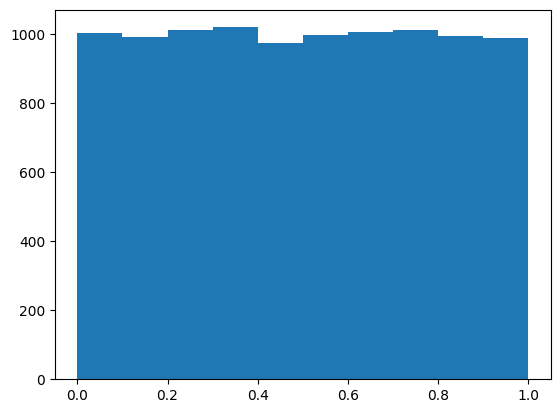

In [3]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import itertools
from sklearn.linear_model import LinearRegression
import random

def generate(n, p, true_beta):
    X = np.random.normal(loc = 0, scale = 1, size = (n,p))

    true_beta = np.reshape(true_beta, (p, 1))

    true_y = np.dot(X, true_beta)
    noise = np.random.normal(loc = 0, scale = 1, size = (n, 1))
    y = true_y + noise

    return X, y, true_y

def naive_p_value(X, y, p):
    XTX = np.dot(X.T, X)
    XTXinv = np.linalg.inv(XTX)
    XTXinvXT = np.dot(XTXinv, X.T)
    beta = np.dot(XTXinvXT, y)

    eta = XTXinvXT.T
    e = np.zeros((p, 1))

    m = random.randint(0, p - 1)
    e[m][0] = 1

    etaTy = np.dot(eta.T, y)
    etaTy_j = np.dot(e.T, etaTy).flatten()[0]

    eta = np.dot(eta, e)

    cdf = norm.cdf(etaTy_j, loc=0, scale=np.sqrt(np.dot(eta.T, eta)[0][0]))
    naive_p_value = 2 * min(1 - cdf, cdf)

    return naive_p_value

if __name__ == '__main__':
    n = 1000
    p = 20
    max_iteration = 10000

    list_p_value = []

    for _ in range(max_iteration):
        true_beta = p * [0]

        X, y_obs, true_y = generate(n, p, true_beta)

        p_value = naive_p_value(X, y_obs, p)
        list_p_value.append(p_value)

    plt.hist(list_p_value, bins = 10)
    plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from itertools import product

import util

def run():
    n = 5

    x_obs, vec_mu, Sigma = util.generate_data(n)

    i_max = np.argmax(np.abs(x_obs))

    eta = np.zeros((n, 1))
    eta[i_max][0] = 1.0

    etaTx_obs = np.dot(eta.T, x_obs)[0][0]

    etaT_Sigma_eta = np.dot(np.dot(eta.T, Sigma), eta)[0][0]

    tn_mu = 0
    tn_Sigma = np.sqrt(etaT_Sigma_eta)

    signs = list(product([1, -1], repeat = n))

    z_intervals = []

    for s in signs:
        interval = util.compute_V(x_obs, n, eta, Sigma, s)

        if interval is not None:
            z_intervals.append(interval)

    p_value = util.compute_truncated_p_value(z_intervals, etaTx_obs, tn_mu, tn_Sigma)

    return p_value

if __name__ == '__main__':
    max_iteration = 10000

    list_p_value = []

    for _ in range(max_iteration):
        p_value = run()
        list_p_value.append(p_value)
        # print('---------------------------------')

    plt.hist(list_p_value, bins = 10)
    plt.show()


ModuleNotFoundError: No module named 'util'

# **Setting 3**

$X = \mu + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \Sigma)$

$j = \arg\max \{ \;x_i\;\}$

Hypothesis:
$H_0: \mu_j = 0, \quad H_1: \mu_j \neq 0$

Test statistisc: $T = x_j = \eta_j^TX$ <br><br>

### Nhận định
Khi ta chọn $T = x_j$ dựa trên $j = \arg\max \{ \;x_i\;\}$ thì $ \ T \ $ lúc này có xu hướng lệch nhiều về phần đuôi bên phải của phân phối chuẩn

Do đó phần lớn các p-value sẽ nằm ở phần bác bỏ $H_0$, khi hist p-value lên ta không còn được kết quả là 1 phân phối đều

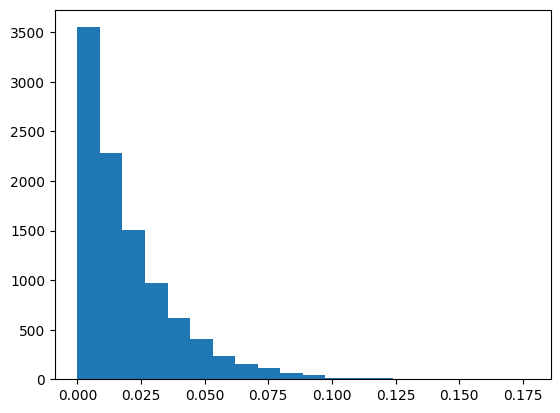

In [7]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import random

def generate(n):
    X = np.random.normal(loc = 0, scale = 1, size = (n, 1))

    return X

def run(x):
    # shape (1, 1) to scalar
    T = x.flatten()[0]

    cdf = norm.cdf(T, loc = 0, scale = 1)
    naive_p_value = 2 * min(cdf, 1 - cdf)

    return naive_p_value

if __name__ == '__main__':
    n = 100
    max_iteration = 10000

    list_p_value = []

    cnt1 = 0
    for _ in range(max_iteration):
        X = generate(n)

        eta = np.zeros((n, 1))
        m_max = np.argmax(X)
        eta[m_max][0] = 1

        p_value = run(np.dot(eta.T, X))
        list_p_value.append(p_value)

    plt.hist(list_p_value, bins = 20)
    plt.show()

# **Setting 4**

$y = \mu + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \Sigma)$

$j = \arg\max \{ \;\beta_i\;\}$

Hypothesis: $H_0: \beta_j^* = 0, \quad H_1: \beta_j^* \neq 0$

Test statistics: $T = \hat{\beta_j} = [(X^TX)^{-1}X^Ty]_j = \eta_j^Ty $ <br><br>


### Nhận định
Chứng minh tương tự như ở *Setting 2* và *Setting 3*

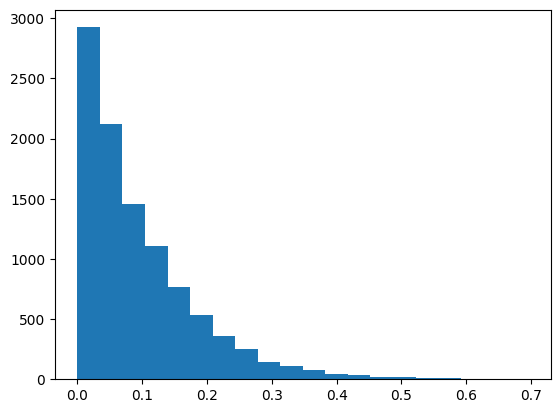

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import itertools
from sklearn.linear_model import LinearRegression
import random

def generate(n, p, true_beta):
    X = np.random.normal(loc = 0, scale = 1, size = (n, p))
    true_beta = np.reshape(true_beta, (p, 1))

    true_y = np.dot(X, true_beta)
    noise = np.random.normal(loc = 0, scale = 1, size = (n, 1))
    y = true_y + noise

    return X, y, true_y

def naive_p_value(X, y, p):
    XTX = np.dot(X.T, X)
    XTXinv = np.linalg.inv(XTX)
    XTXinvXT = np.dot(XTXinv, X.T)
    beta = np.dot(XTXinvXT, y)

    eta = XTXinvXT.T
    e = np.zeros((p, 1))

    etaTy = np.dot(eta.T, y)
    m_max = np.argmax(etaTy)
    e[m_max][0] = 1
    etaTy_j = np.dot(e.T, etaTy).flatten()[0] # shape (1, 1) to scalar

    cdf = norm.cdf(etaTy_j, loc = 0, scale = np.sqrt(np.dot(eta.T, eta)[m_max][m_max]))
    naive_p_value = 2 * min(1 - cdf, cdf)

    return naive_p_value

if __name__ == '__main__':
    n = 1000
    p = 20
    max_iteration = 10000

    list_p_value = []

    for _ in range(max_iteration):
        true_beta = p * [0]

        X, y_obs, true_y = generate(n, p, true_beta)

        p_value = naive_p_value(X, y_obs, p)
        list_p_value.append(p_value)

    plt.hist(list_p_value, bins = 20)
    plt.show()

### Post-selective inference for setting 3

$X = \mu + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \Sigma)$

$j = \arg\max \{ \;x_i\;\}$

Hypothesis:
$H_0: \mu_j = 0, \quad H_1: \mu_j \neq 0$

Test statistisc: $T = x_j = \eta_j^TX, \; $  under the selection event:
$$
x_i - x_j \leq 0, \;\; \forall i = 1, \dots, n
.
$$

In [8]:
import numpy as np
from mpmath import mp
import matplotlib.pyplot as plt

mp.dps = 500

def run():
    n = 100
    mu_vec = np.zeros((n, 1))
    Sigma = np.identity(n)

    x_obs = np.random.multivariate_normal(mu_vec.flatten(), Sigma)
    x_obs = x_obs.reshape((n, 1))

    i_max = np.argmax(x_obs)

    eta = np.zeros((n, 1))
    eta[i_max][0] = 1.0

    # We want to the following hypothesis
    # H_0 = mu_{i_max} = 0  vs.  H_1 = mu_{i_max} != 0

    etaTx_obs = np.dot(eta.T, x_obs)[0][0]

    A = None
    b = None

    for i in range(n):
        # x_i <= x_i_max <=> x_i - x_i_max <= 0

        e_i = np.zeros((n, 1))
        e_i[i][0] = 1.0

        e_i_max = np.zeros((n, 1))
        e_i_max[i_max][0] = 1.0

        if A is None:
            A = (e_i - e_i_max).T
            b = [0]
        else:
            A = np.vstack((A, (e_i - e_i_max).T))
            b = np.vstack((b, 0))

    # Compute vector c in Equation 5.3 of Lee et al. 2016
    etaT_Sigma_eta = np.dot(np.dot(eta.T, Sigma), eta)[0][0]
    c = np.dot(Sigma, eta) / etaT_Sigma_eta

    # Compute vector z in Equation 5.2 of Lee et al. 2016
    z = np.dot(np.identity(n) - np.dot(c,  eta.T), x_obs)

    # Following Lemma 5.1 of Lee et al. 2016 to compute V^{-} and V^{+}
    Az = np.dot(A, z)
    Ac = np.dot(A, c)

    Vminus = -np.inf
    Vplus = np.inf

    for j in range((len(b))):
        left = np.around(Ac[j][0], 20)
        right = np.around(b[j][0] - Az[j][0], 20)

        if (left == 0):
            if (right < 0):
                print('Error')
        else:
            temp = right / left

            if (left > 0):
                Vplus = min(Vplus, temp)
            else:
                Vminus = max(Vminus, temp)


    # Compute CDF of the truncated Gaussian distribution
    numerator = mp.ncdf(etaTx_obs / np.sqrt(etaT_Sigma_eta)) - mp.ncdf(Vminus / np.sqrt(etaT_Sigma_eta))
    denominator = mp.ncdf(Vplus / np.sqrt(etaT_Sigma_eta)) - mp.ncdf(Vminus / np.sqrt(etaT_Sigma_eta))
    cdf = float(numerator / denominator)

    # Compute 2-sided selective p-value
    selective_p_value = 2 * min(cdf, 1 - cdf)

    return selective_p_value

if __name__ == '__main__':
    max_iteration = 10000

    list_p_value = []

    for _ in range(max_iteration):
        p_value = run()
        list_p_value.append(p_value)

    plt.hist(list_p_value, bins = 10)
    plt.show()


ModuleNotFoundError: No module named 'mpmath'

### **Post-selection inference for setting 3.1**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpmath import mp

mp.dps = 500

def run():
    n = 100

    mu_vec = np.zeros((n, 1))
    Sigma = np.identity(n)

    x_obs = np.random.multivariate_normal(mu_vec.flatten(), Sigma)
    x_obs = x_obs.reshape((n, 1))

    i_max = np.argmax(np.abs(x_obs))

    eta = np.zeros((n, 1))
    eta[i_max][0] = 1.0

    # We want the following hypothesis
    # H0: mu_{i_max} = 0  vs.  H1: mu_{i_max} != 0

    etaTx_obs = np.dot(eta.T, x_obs)

    A = None
    b = None

    cnt = 0
    for i in range(n):
        # |x_i| <= |x_i_max| <=> sign(x_i_obs) * x_i - sign(x_i_max_obs) * x_i_max <= 0

        e_i = np.zeros((n, 1))
        e_i[i][0] = np.sign(x_obs[i][0])

        e_i_max = np.zeros((n, 1))
        e_i_max[i_max][0] = np.sign(etaTx_obs[0][0])

        if A is None:
            A = (e_i - e_i_max).T
            b = [0]
        else:
            A = np.vstack((A, (e_i - e_i_max).T))
            b = np.vstack((b, 0))

        # sign(x_i_obs) * x_i >= 0

        # e_i = np.zeros((n, 1))
        # e_i[i][0] = -np.sign(x_obs[i][0])

        # A = np.vstack((A, e_i.T))
        # b = np.vstack((b, 0))

    # Compute vector c in Equation 5.3 of Lee et al. 2016
    etaT_Sigma_eta = np.dot(np.dot(eta.T, Sigma), eta)[0][0]
    c = np.dot(Sigma, eta) / etaT_Sigma_eta

    # Compute vector z in Equation 5.2 of Lee et al. 2016
    z = np.dot(np.identity(n) - np.dot(c, eta.T), x_obs)

    # Following Lemma 5.1 of Lee et al. 2016 to compute V^{-} and V^{+}
    Az = np.dot(A, z)
    Ac = np.dot(A, c)
    # print(np.dot((e_i - e_i_max).T, x_obs))

    Vminus = -np.inf
    Vplus = np.inf

    cnt = 0
    for j in range((len(b))):
        left = np.around(Ac[j][0], 20)
        right = np.around(b[j][0] - Az[j][0], 20)

        if (left == 0):
            if (right < 0):
                print('Error')
        elif (left > 0):
            Vplus = min(Vplus, right / left)
        else:
            Vminus = max(Vminus, right / left)

    print(Vminus, Vplus)
    # Compute CDF of the truncated Gaussian distribution
    numerator = mp.ncdf(etaTx_obs[0][0] / np.sqrt(etaT_Sigma_eta)) - mp.ncdf(Vminus / np.sqrt(etaT_Sigma_eta))
    denominator = mp.ncdf(Vplus / np.sqrt(etaT_Sigma_eta)) - mp.ncdf(Vminus / np.sqrt(etaT_Sigma_eta))
    cdf = float(numerator / denominator)

    # Compute 2-sided selective p-value
    selective_p_value = 2 * min(cdf, 1 - cdf)

    return selective_p_value

if __name__ == '__main__':
    max_iteration = 1

    list_p_value = []

    for _ in range(max_iteration):
        p_value = run()
        list_p_value.append(p_value)

    # plt.hist(list_p_value, bins = 20)
    # plt.show()


2.5274265308818324 inf


### Post-selective inference for setting 4

$y = \mu + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \Sigma)$

$j = \arg\max \{ \;\beta_i\;\}$

Hypothesis: $H_0: \beta_j^* = 0, \quad H_1: \beta_j^* \neq 0$

Test statistics: $T = \hat{\beta_j} = [(X^TX)^{-1}X^Ty]_j = \eta_j^Ty, \; $ under the selection event:

$$
\beta_i - \beta_j \leq 0, \;\; \forall i = 1, \dots, n.
$$

We get:

$$ \eta_i^Ty - \eta_j^Ty \leq 0, \;\; \forall i = 1, \dots, n.  $$


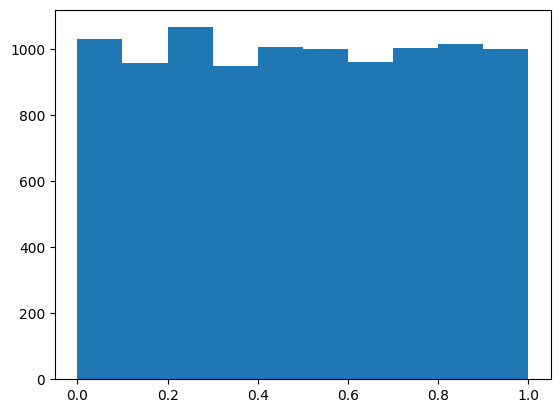

In [ ]:
import numpy as np
from mpmath import mp
import matplotlib.pyplot as plt

mp.dps = 500

cnt = 0
def generate(n, p, true_beta):
    X = np.random.normal(loc = 0, scale = 1, size = (n, p))

    true_y = np.dot(X, true_beta)
    noise = np.random.normal(loc = 0, scale = 1, size = (n, 1))
    y = true_y + noise

    return X, y, true_y

def run():
    n = 100
    p = 10

    Sigma = np.identity(n)
    true_beta = np.zeros((p, 1))
    X, y, y_true = generate(n, p, true_beta)

    XTX = np.dot(X.T, X)
    XTXinv = np.linalg.inv(XTX)
    XTXinvXT = np.dot(XTXinv, X.T)

    eta = XTXinvXT.T
    etaTy = np.dot(eta.T, y)

    i_max = np.argmax(etaTy)
    e = np.zeros((p, 1))
    e[i_max] = 1.0

    etaTy = np.dot(e.T, etaTy)

    A = None
    b = None

    for i in range(p):
        if A is None:
            A = (eta.T[i] - eta.T[i_max])
            b = [0]
        else:
            A = np.vstack((A, (eta.T[i] - eta.T[i_max])))
            b = np.vstack((b, 0))

    eta = np.dot(eta, e)

    # Compute vector c in Equation 5.3 of Lee et al. 2016
    etaT_Sigma_eta = np.dot(np.dot(eta.T, Sigma), eta)

    c = np.dot(np.dot(Sigma, eta), np.linalg.inv(etaT_Sigma_eta))

    # Compute vector z in Equation 5.2 of Lee et al. 2016
    z = np.dot(np.identity(n) - np.dot(c,  eta.T), y)

    # Following Lemma 5.1 of Lee et al. 2016 to compute V^{-} and V^{+}
    Az = np.dot(A, z)
    Ac = np.dot(A, c)

    Vminus = -np.inf
    Vplus = np.inf

    for j in range((len(b))):
        left = np.around(Ac[j][0], 20)
        right = np.around(b[j][0] - Az[j][0], 20)

        if (left == 0):
            if (right < 0):
                print('Error')
        else:
            temp = right / left

            if (left > 0):
                Vplus = min(Vplus, temp)
            else:
                Vminus = max(Vminus, temp)

    truncated_Sigma = etaT_Sigma_eta[0][0]

    # Compute CDF of the truncated Gaussian distribution
    numerator = mp.ncdf(etaTy[0][0] / np.sqrt(truncated_Sigma)) - mp.ncdf(Vminus / np.sqrt(truncated_Sigma))
    denominator = mp.ncdf(Vplus / np.sqrt(truncated_Sigma)) - mp.ncdf(Vminus / np.sqrt(truncated_Sigma))
    cdf = float(numerator / denominator)

    # Compute 2-sided selective p-value
    selective_p_value = 2 * min(cdf, 1 - cdf)

    if (etaTy[0][0] > Vplus): cnt += 1

    return selective_p_value

if __name__ == '__main__':
    max_iteration = 10000

    list_p_value = []

    for _ in range(max_iteration):
        p_value = run()
        list_p_value.append(p_value)


    plt.hist(list_p_value)
    plt.show()
